*Integrantes:*

Nicolás Azzoni Furno

Pablo Rafael Barchiesi

Ricardo Gabriel Lehmann

# Programación para el Análisis de Datos
## Trabajo Práctico - Matrices de Insumo Producto

### Enunciado

### Consigna 1 - 

Implementar la función en Python calcularLeontief(A), que recibe una
matriz A de tipo ndarray y devuelve la matriz L de acuerdo a la fórmula de la ecuación
2.

In [1]:
# la funcion está en funciones.py
import funciones as ftp #funciones trabajo practico

### Consigna 2 -

Resolver el sistema 2 utilizando calcularLeontief(A) para los siguientes
valores de A y d:
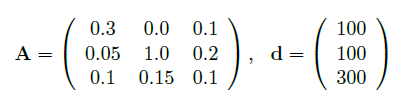

respondiendo lo siguiente:

¿Hay una justifícación económica de los valores encontrados para p?


¿Cuál es la característica de la matriz que lleva a esta solución?

In [2]:
import numpy as np
import pandas as pd
productos = ['Producto 1', 'Producto 2', 'Producto 3'] # vector solo para presentación de datos más clara

# A: matriz de coeficientes técnicos (insumos requeridos por unidad producida)
A = np.array([
    [0.3,0.0,0.1],
    [0.05,1.0,0.2],
    [0.1,0.15,0.1]
])

d = np.array([100,100,300]).reshape(3,1) # demanda externa

L = ftp.calcularLeontief(A)


#dataframe para presentación mas clara
L_df = pd.DataFrame(
    L,
    index = productos,
    columns=productos
)

# p: producción total necesaria para satisfacer la demanda externa d
p = L @ d

#dataframe para presentación mas clara
p_df = pd.DataFrame(
    p,
    index = productos,
    columns= ['Cantidad']
)

print('Matriz de Leontief (L)')
print (L_df)
print('---------------------------------------------------')
print('Produccion:')
print (p_df)


Matriz de Leontief (L)
            Producto 1  Producto 2  Producto 3
Producto 1    1.379310   -0.689655    0.000000
Producto 2   -2.988506  -28.505747   -6.666667
Producto 3   -0.344828   -4.827586   -0.000000
---------------------------------------------------
Produccion:
               Cantidad
Producto 1    68.965517
Producto 2 -5149.425287
Producto 3  -517.241379


---

*Caracteristicas de A:*

A[1,1] = 1, lo que significa que el sector 2, para producir una unidad del producto 2, necesita consumir una unidad de su producto. Presenta una dependencia excesiva de autoconsumo, lo que genera resultados económicamente difíciles de justificar.

Un ejemplo absurdo: Una panadería necesita 1 kilo de pan para producir 1 kilo de pan, es decir, no se está produciendo nada nuevo.


*Comentarios de la producción*:

Sector 1: p1 = 68.96...

Presenta una magnitud moderada comparada con la demanda externa

Sector 2: p2 = -5.149,42...

Representa una producción negativa muy grande. No tiene sentido económico ya que no se pueden producir unidades negativas, lo que implicaría destrucción del producto

El sector 2 no puede satisfacer la demanda externa

Sector 3: p3 = -517,24...

Al igual que el producto 2 es un valor negativo pero con una menor magnitud. Indica que el problema del sector 2 se propaga al resto del sistema



### Consigna 3 -

Esta consigna analiza qué sucede con la producción total cuando a partir
de una demanda externa d, la demanda externa para el producto 3 cambia en un Δd.
La demanda externa se convierte en
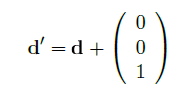

Implementar una función deltaProduccion(L, delta_d). Obtener la expresión del vector Δp correspondiente a este ejemplo.

In [3]:
# delta_d: shock unitario en la demanda externa del Producto 3
delta_d = np.array([0,0,1]).reshape(3,1)


delta_p = ftp.deltaProduccion(L,delta_d) #delta produccion

delta_p_df = pd.DataFrame(
    delta_p,
    index = productos,
    columns = ['Delta Cantidad']
) #solo a efectos de presentacion

print('Variación de la producción por producto ante el shock de demanda:')
print(delta_p_df)

Variación de la producción por producto ante el shock de demanda:
            Delta Cantidad
Producto 1        0.000000
Producto 2       -6.666667
Producto 3        0.000000


### Consigna 3 bis -

Consigna 3 bis. A partir del modelo trabajado en la Consigna 3, construir una secuencia
de 'shocks' sobre la demanda externa del producto 3 (un shock es una variación
abrupta de la demanda). Por ejemplo, considerar valores entre 0 y 20 unidades, o bien
entre −10 y 10 unidades, con incrementos regulares. Para cada valor del shock, calcular
el correspondiente vector de variación de producción Δp.

Luego:
Grafícar con matplotlib la respuesta de cada sector, es decir Δp1, Δp2 y Δp3, en
función del tamaño del shock.

Interpretar cuál de los sectores presenta mayor sensibilidad ante cambios en la
demanda externa del producto 3.

Comentar si la relación observada entre shock y respuesta parece lineal, y justficarlo
a partir del modelo de Leontief.

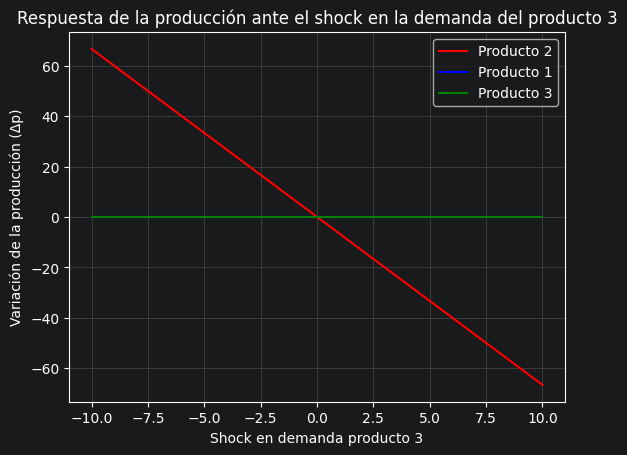

In [4]:
seq_shock_p3 = np.arange(-10,11) #unidades del -10 al 10 para producto 3
ceros = np.zeros(21) # ceros para completar el producto 1 y 2
matriz_seq_shock = np.array([
    ceros,
    ceros,
    seq_shock_p3
])

delta_sequencia_shock = ftp.deltaProduccion(L,matriz_seq_shock) #datos para el grafico

import matplotlib.pyplot as plt
plt.plot(range(-10,11),delta_sequencia_shock [1], label ='Producto 2',c = 'red')
plt.plot(range(-10,11),delta_sequencia_shock [0], label ='Producto 1', c = 'blue')
plt.plot(range(-10,11),delta_sequencia_shock [2], label ='Producto 3', c= 'green')
plt.xlabel('Shock en demanda producto 3')
plt.ylabel ('Variación de la producción (Δp)')
plt.title('Respuesta de la producción ante el shock en la demanda del producto 3')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


El sector que presenta mayor sensibilidad ante cambios en la demanda del producto 3 es el sector 2. En particular, por cada unidad adicional de demanda externa del producto 3, la producción del sector 2 debe reducirse en aproximadamente 6,67 unidades


La relación observada entre el tamaño del shock en la demanda y la variación de la producción es lineal. Esto se explica porque el modelo de Leontief es un modelo lineal. Los cambios en la demanda externa se transmiten de manera proporcional a la producción de cada sector, dando lugar a respuestas lineales frente a shocks de distinta magnitud.

### Consigna 4

Implementar la función calcularCoeficientes(Z, totales) que recibe
la matriz Z con unidades monetarias, los totales de cada sector y devuelve la matriz A
de coecientes técnicos.

In [5]:
# funcion declarada en funciones py

### Consigna 5

Encontrar los coeficientes técnicos A y la matriz de Leontief para la
siguiente economía.
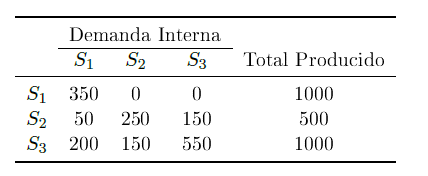

In [6]:
Z = np.array([
    [350,0,0],
    [50,250,150],
    [200,150,550]
]) #demanda interna medida en unidades monetarias
total_producido = np.array([1000,500,1000]) #debe ser un vector para calcular la diagonal (no hacer reshape)

A = ftp.calcularCoeficientes(Z,total_producido) #coeficientes tecnicos

A_df = pd.DataFrame(
    A,
    index = productos,
    columns = productos
) #solo a efectos de presentación

L = ftp.calcularLeontief(A) # leontief de A

L_df = pd.DataFrame(
    L,
    index = productos,
    columns = productos
)#solo a efectos de presentación
print('Coeficientes Técnicos A (insumos por unidad producida)')
print(A_df)
print('-----------------------------')
print('Leontief de A')
print(L_df)

Coeficientes Técnicos A (insumos por unidad producida)
            Producto 1  Producto 2  Producto 3
Producto 1        0.35         0.0        0.00
Producto 2        0.05         0.5        0.15
Producto 3        0.20         0.3        0.55
-----------------------------
Leontief de A
            Producto 1  Producto 2  Producto 3
Producto 1    1.538462    0.000000    0.000000
Producto 2    0.448718    2.500000    0.833333
Producto 3    0.982906    1.666667    2.777778


### Consigna 5 - bis

Visualización de matrices económicas. Tomando la matriz de coeficientes técnicos A calculada la consigna 5, y su correspondiente matriz de Leontief L,realizar un análisis gráfico utilizando la librería seaborn.

En particular:

Construir un mapa de calor (heatmap) para la matriz de coeficientes técnicos A.

Construir un segundo mapa de calor para la matriz de Leontief L.

Comparar ambas visualizaciones y comentar qué diferencias se observan entre los encadenamientos directos representados en A y los efectos totales representados en L.

Se espera una breve interpretación económica de los patrones observados en las figuras.

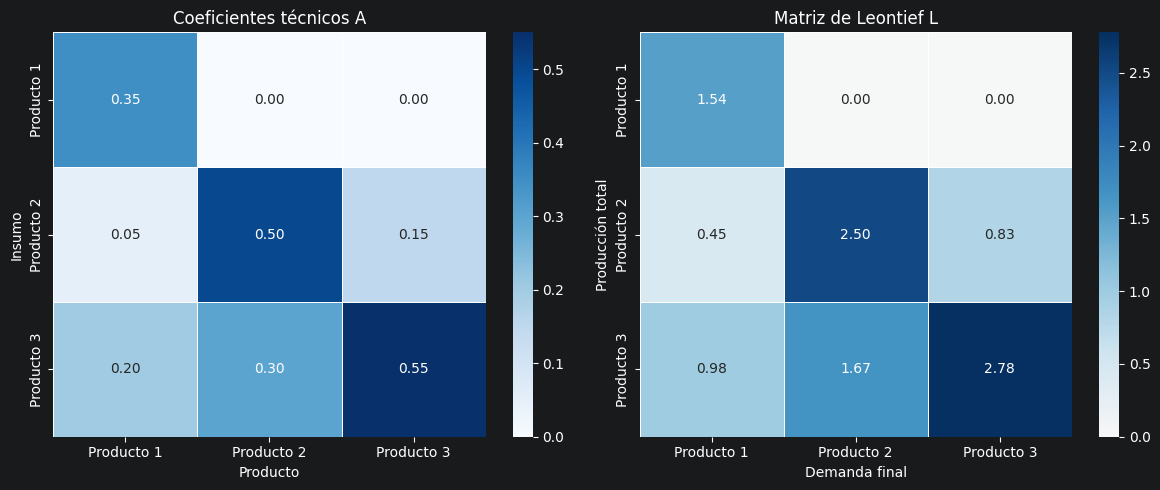

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap de A
sns.heatmap(
    A_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Coeficientes técnicos A")
axes[0].set_xlabel("Producto")
axes[0].set_ylabel("Insumo")

# Heatmap de L
sns.heatmap(
    L_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("Matriz de Leontief L")
axes[1].set_xlabel("Demanda final")
axes[1].set_ylabel("Producción total")

plt.tight_layout()
plt.show()

En el mapa de calor se observa que los coeficientes son relativamente acotados y no negativos, lo que indica que cada sector requiere insumos de otros sectores en proporciones moderadas. Por ejemplo, el Producto 3 presenta una fuerte dependencia directa tanto de su propio sector (0.55) como del Producto 2 (0.30), mientras que el Producto 1 muestra una estructura más simple, con dependencia principalmente interna (0.35). En general, la matriz A describe una tecnología productiva estable, donde los requerimientos de insumos por unidad producida son menores a uno.


En contraste, la matriz de Leontief los coeficientes presentan valores notablemente mayores. Por ejemplo, una unidad adicional de demanda final del Producto 3 requiere aproximadamente 2.78 unidades de producción del propio sector, 1.67 unidades del Producto 2 y 0.98 unidades del Producto 1, evidenciando una fuerte amplificación de los requerimientos productivos. De manera similar, la demanda final del Producto 2 genera respuestas significativas en todos los sectores, lo que revela un alto grado de interdependencia.


La comparación entre ambos mapas de calor muestra con claridad cómo los encadenamientos directos representados en A se ven amplificados al considerar la totalidad de las relaciones productivas en L. Mientras que la matriz A refleja relaciones técnicas locales, la matriz de Leontief captura el impacto sistémico de la demanda final, dando cuenta de la importancia de los efectos indirectos en la determinación de la producción total. En este sentido, los resultados sugieren que los sectores 2 y 3 actúan como sectores clave dentro de la economía, ya que pequeñas variaciones en su demanda final generan efectos multiplicadores significativos sobre el conjunto del sistema productivo.

### Consigna 6

Implementar en la función calcularLeontiefInterregional(Arr, Ars, Ass, Asr) la ecuación 6.

In [8]:
#funcion definida en funciones.py

### Consigna 7

Descargar de este link, en la sección Adjuntos, la MIP Latinoamericana 2011 (Preliminar). Este es un archivo de Excel, el cual deben leer con la librería pandas de Python. En la Hoja 'LAT_IOT_2011' se encontrarán los flujos entre 40 sectores de 18 paises, expresados en millones de dólares. La última columna del archivo, con el título 'Output' es el total producido para ese sector.




In [9]:
#descarga del excel
archivo = 'matrizlatina2011_compressed_0.xlsx'
hoja = 'LAC_IOT_2011'
datos = pd.read_excel(archivo,hoja)
#en este caso el archivo fue recorrido desde el excel, comprendiendo su contenido
# Columna Country_iso3 tiene los paises. Valido para filtar ARG y BRA
# Nosector = numero del sector
# Sector = nombre del sector
#luego 40 columnas de arg y 40 columnas de brasil
#por ultimo Output tiene el vector de producción total

Las dos regiones que vamos a trabajar van a ser P1: Argentina, P2: Brasil. Generar la matriz de Insumo-Producto de estas dos regiones.

Calcular los coeficientes técnicos para cada bloque en sus submatrices intra-regionales e inter-regionales de la A total.




In [10]:
#Regiones brasil y argentina. Filtro filas y columnas
datos_arg_bra = datos[datos['Country_iso3'].isin(['ARG','BRA'])]
datos_arg = datos_arg_bra[datos_arg_bra['Country_iso3'] =='ARG']
datos_bra = datos_arg_bra[datos_arg_bra['Country_iso3'] =='BRA']
cols_arg = [c for c in datos.columns if c.startswith('ARG')]
cols_bra = [c for c in datos.columns if c.startswith('BRA')]



In [11]:
#Matrices interregionales
# Z_rr ARG - ARG
# Z_rs ARG - BRA
# Z_sr BRA - ARG
# Z_ss BRA - BRA
# filas = quien produce
# columnas = quien compra

Z_rr = datos_arg[cols_arg].values
Z_rs = datos_arg[cols_bra].values
Z_sr = datos_bra[cols_arg].values
Z_ss = datos_bra[cols_bra].values


P_arg = datos_arg['Output'].values #produccion argentina
P_bra = datos_bra['Output'].values # produccion brasil


In [12]:
# Coeficientes:
A_rr = ftp.calcularCoeficientes(Z_rr,P_arg) # intra argentina
A_ss = ftp.calcularCoeficientes(Z_ss,P_bra) # intra brasil
A_sr = ftp.calcularCoeficientes(Z_sr,P_arg) #  argentina - brasil
A_rs = ftp.calcularCoeficientes(Z_rs,P_bra) #  brasil - argentina

In [13]:
L_inter = ftp.calcularLeontiefInterregional(A_rr, A_rs, A_ss, A_sr)




Elegir una visualización que permita comparar entre las dos regiones los diez sectores con mayor interrelación



In [14]:

inter_arg = A_rs.sum(axis=1)  # insumos importados por Argentina
inter_bra = A_sr.sum(axis=1)  # insumos importados por Brasil


sectores = datos_arg['Sector'].values # dato que usare para graficar

inter_arg_s = pd.Series(inter_arg, index=sectores, name='Argentina') #para graficar
inter_bra_s = pd.Series(inter_bra, index=sectores, name='Brasil') #para graficar

inter_total = inter_arg_s + inter_bra_s # sumo los coeficientes de arg y bra
top10 = inter_total.sort_values(ascending=False).head(10) #me quedo con los 10 mayores



In [15]:

top10_df = pd.DataFrame({
    'Argentina': inter_arg_s.loc[top10.index], #filtro de los 10 mayores
    'Brasil': inter_bra_s.loc[top10.index]
})


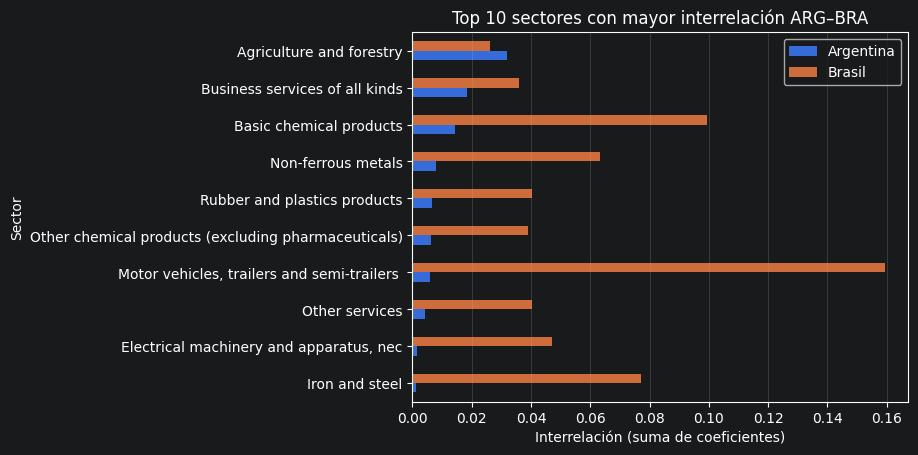

In [16]:

top10_df.sort_values('Argentina').plot(

    kind='barh'

)

plt.title('Top 10 sectores con mayor interrelación ARG–BRA')
plt.xlabel('Interrelación (suma de coeficientes)')
plt.ylabel('Sector')
plt.grid(axis='x', alpha=0.3)
plt.show()


Simular un shock negativo sobre el sector s05 del 10% del total del sector, y un shock positivo del 3.3% del total de cada uno de los siguientes sectores: s06, s07 y s08. Todos estos shocks se producen en el país P1.




In [23]:
#filas a ajustar

fila_s05 = 4
fila_s06 = 5
fila_s07 = 6
fila_s08 = 7

delta_arg = np.zeros(len(P_arg)) #primero lleno todo con ceros


delta_arg[fila_s05] = -0.10 * P_arg[fila_s05]
delta_arg[fila_s06] =  0.033 * P_arg[fila_s06]
delta_arg[fila_s07] =  0.033 * P_arg[fila_s07]
delta_arg[fila_s08] =  0.033 * P_arg[fila_s08]

#delta_arg contiene ya los shocks

Analizar cómo se modifica la producción cuando se considera el modelo de región simple (ecuación 5) y cuando se considera la fórmula completa de las 2 regiones
(ecuación 6).

In [26]:
#Modelo simple

L_arg_simple = ftp.calcularLeontief(A_rr)
delta_arg_simple = ftp.deltaProduccion(L_arg_simple,delta_arg)

#Modelo interregional
delta_inter = ftp.deltaProduccion(L_inter,delta_arg)


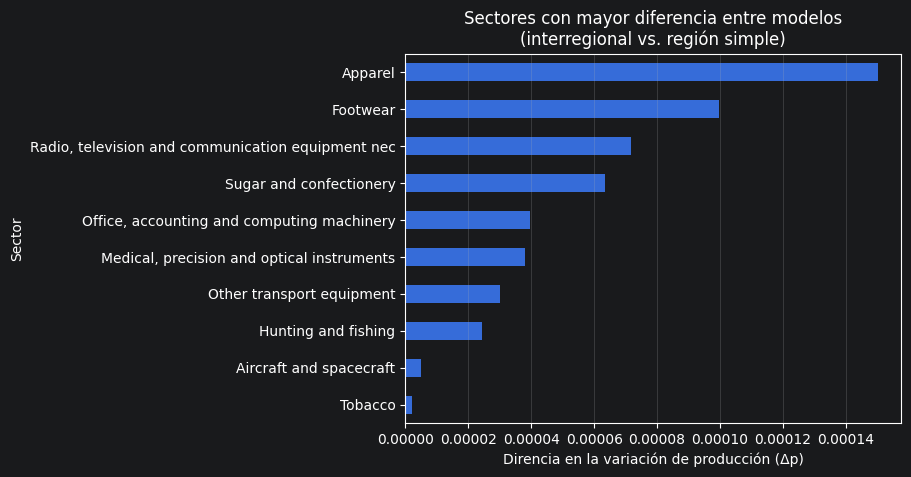

In [31]:

comparacion_df = pd.DataFrame({
    'Modelo simple': delta_arg_simple,
    'Modelo interregional': delta_inter
}, index=datos_arg['Sector'])

comparacion_df_dif = (comparacion_df['Modelo interregional'] - comparacion_df['Modelo simple']).sort_values()

comparacion_df_dif.head(10).plot(

    kind='barh'

)

plt.title('Sectores con mayor diferencia entre modelos\n(interregional vs. región simple)')
plt.xlabel('Difrencia en la variación de producción (Δp)')
plt.ylabel('Sector')
plt.grid(axis='x', alpha=0.3)
plt.show()


### Consigna 7 - bis

Análisis gráfico del caso real con dos regiones. A partir del caso real trabajado en la Consigna 6, construir una secuencia de intensidades para el shock defnido sobre el país P1. Considerar shocks negativos sobre el sector s05 de −2%, −4%,
−6%, −8% y −10% del total del sector, manteniendo proporcionalmente los shocks
positivos sobre los sectores s06, s07 y s08.


Para cada intensidad del shock:


Calcular la variación de la producción sectorial bajo el modelo de región simple.


Calcular la variación de la producción sectorial bajo el modelo completo de dos regiones.


Obtener, para cada modelo, la variación total de la producción en P1 y en P2.


Luego realizar las siguientes visualizaciones:

Graficar con matplotlib la variación total de producción de P1 y P2 en función de
la intensidad del shock, comparando el modelo simple y el modelo de dos regiones.
Para el escenario de mayor intensidad, graficar con seaborn un diagrama de barras
con los 10 sectores más afectados en términos absolutos.


Construir con seaborn un mapa de calor (heatmap) que muestre la diferencia sector
por sector entre la variación estimada por el modelo de dos regiones y la estimada
por el modelo simple.


Finalmente, discutir brevemente qué aporta la incorporación de relaciones interregionales al análisis de los efectos del shock.

In [44]:
sec_intensidades = np.array([-0.02, -0.04, -0.06, -0.08, -0.10])


resultados = []
L_arg_simple = ftp.calcularLeontief(A_rr)

for i in sec_intensidades:
    delta_d = np.zeros(len(P_arg))

    delta_d[fila_s05] = i * P_arg[fila_s05]
    delta_d[fila_s06] = -i * 0.33 * P_arg[fila_s06]
    delta_d[fila_s07] = -i * 0.33 * P_arg[fila_s07]
    delta_d[fila_s08] = -i * 0.33 * P_arg[fila_s08]


    # Modelo simple

    dp_simple_arg = ftp.deltaProduccion(L_arg_simple,delta_d)

    # Modelo interregional (Argentina)
    dp_inter_arg = ftp.deltaProduccion(L_inter,  delta_d)

    # Efecto sobre Brasil usando encadenamientos
    dp_inter_bra = (
        np.linalg.inv(np.eye(A_ss.shape[0]) - A_ss)
        @ A_sr @ dp_inter_arg
    )

    resultados.append({
        'intensidad': abs(i)*100,
        'ARG_simple': dp_simple_arg.sum(),
        'ARG_inter': dp_inter_arg.sum(),
        'BRA_inter': dp_inter_bra.sum()
    })
res_df = pd.DataFrame(resultados)

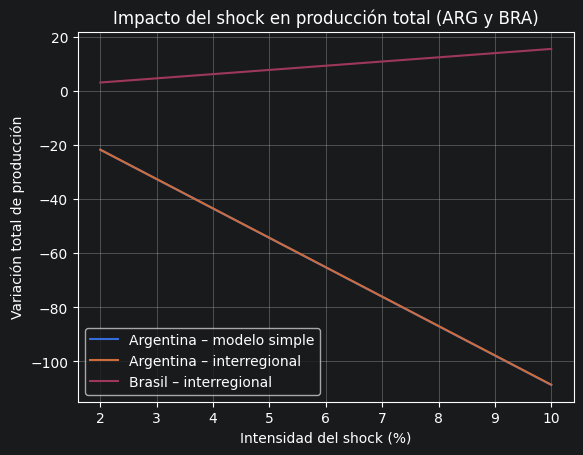

In [45]:
plt.plot(res_df['intensidad'], res_df['ARG_simple'], label='Argentina – modelo simple')
plt.plot(res_df['intensidad'], res_df['ARG_inter'], label='Argentina – interregional')
plt.plot(res_df['intensidad'], res_df['BRA_inter'], label='Brasil – interregional')

plt.xlabel('Intensidad del shock (%)')
plt.ylabel('Variación total de producción')
plt.title('Impacto del shock en producción total (ARG y BRA)')
plt.legend()
plt.grid()
plt.show()

In [46]:

i = -0.10
delta_d_max = np.zeros(len(P_arg))

delta_d_max[fila_s05] = i * P_arg[fila_s05]
delta_d_max[fila_s06] = -i * 0.33 * P_arg[fila_s06]
delta_d_max[fila_s07] = -i * 0.33 * P_arg[fila_s07]
delta_d_max[fila_s08] = -i * 0.33 * P_arg[fila_s08]


dp_simple_max = ftp.deltaProduccion(L_arg_simple, delta_d_max)
dp_inter_max = ftp.deltaProduccion(L_inter, delta_d_max)




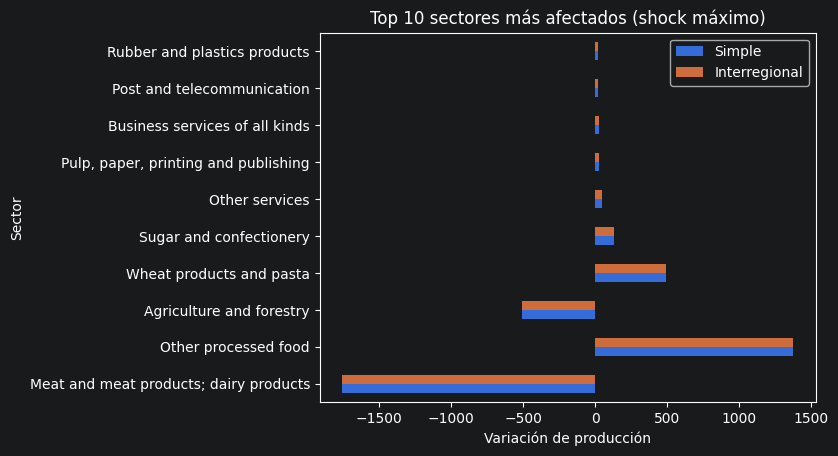

In [47]:
df_sector = pd.DataFrame({
    'Simple': dp_simple_max.flatten(),
    'Interregional': dp_inter_max.flatten()
}, index=datos_arg['Sector'])

top10 = df_sector.abs().sum(axis=1).sort_values(ascending=False).head(10)

df_sector.loc[top10.index].plot(kind='barh')
plt.title('Top 10 sectores más afectados (shock máximo)')
plt.xlabel('Variación de producción')
plt.show()

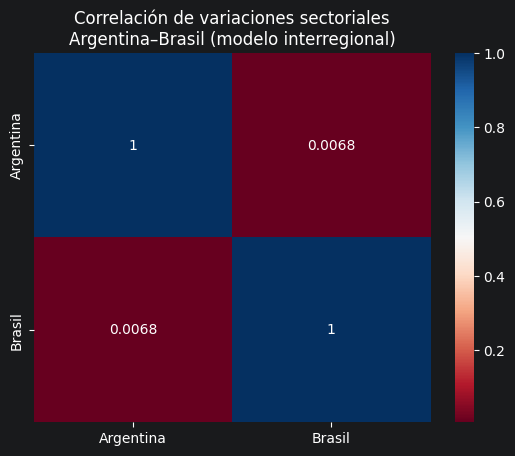

In [54]:

df_corr = pd.DataFrame({
    'Argentina': dp_inter_arg.flatten(),
    'Brasil': dp_inter_bra.flatten()
}, index=datos_arg['Sector'])


corr_matrix = df_corr.corr()



sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu'
    )

plt.title('Correlación de variaciones sectoriales\nArgentina–Brasil (modelo interregional)')
plt.show()

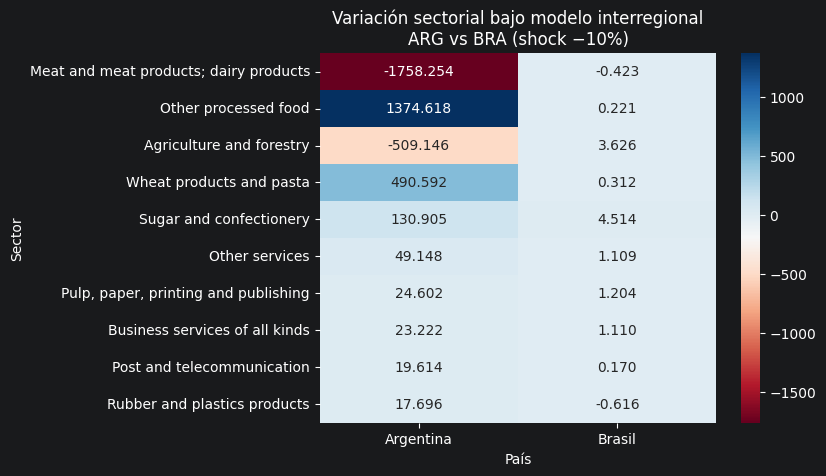

In [53]:
top = df_corr.abs().sum(axis=1).sort_values(ascending=False).head(10)

sns.heatmap(
    df_corr.loc[top.index],
    cmap='RdBu',

    annot=True,

    fmt='.3f'
)

plt.title('Variación sectorial bajo modelo interregional\nARG vs BRA (shock −10%)')
plt.xlabel('País')
plt.ylabel('Sector')
plt.show()